## Imports

In [167]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

## Read excel dataset

In [168]:
data = pd.read_csv('Dados_Projeto_de_Investigação_Leo.csv')
print(data.shape)
data.head()

(103, 14)


,Número de Utente,Ano,Mês,Idade,Género,Formato,Lateralidade,Lado,Etiologia,Encaixe,Suspensão,Comprimento Descrição,Comprimento Valor(cm),Volume (dm^3)
0,1,2018,Dezembro,61,Feminino,Cilíndrico,Unilateral,Esquerdo,Vascular,PTB,PIN,Médio,14.20,1.1750
1,1,2018,Setembro,61,Feminino,Cilíndrico,Unilateral,Esquerdo,Vascular,PTB,PIN,Médio,14.60,1.3500
2,1,2022,Outubro,61,Feminino,Cilíndrico,Unilateral,Esquerdo,Vascular,PTB,PIN,Médio,12.99,0.9460
3,2,2018,Fevereiro,82,Masculino,Cilíndrico,Unilateral,Esquerdo,Vascular,PTB,PIN,Curto,9.85,0.6165
4,2,2018,Março,82,Masculino,Cilíndrico,Unilateral,Esquerdo,Vascular,PTB,PIN,Curto,11.10,0.7930


In [169]:
meses = {
    'Janeiro': 1, 'Fevereiro': 2, 'Março': 3, 'Abril': 4,
    'Maio': 5, 'Junho': 6, 'Julho': 7, 'Agosto': 8,
    'Setembro': 9, 'Outubro': 10, 'Novembro': 11, 'Dezembro': 12
}

# Apply mapping
data['Mês_num'] = data['Mês'].map(meses)
data['Data'] = pd.to_datetime(
    data.rename(columns={'Ano': 'year', 'Mês_num': 'month'}).loc[:, ['year', 'month']].assign(day=1)
)

data.head()

,Número de Utente,Ano,Mês,Idade,Género,Formato,Lateralidade,Lado,Etiologia,Encaixe,Suspensão,Comprimento Descrição,Comprimento Valor(cm),Volume (dm^3),Mês_num,Data
0,1,2018,Dezembro,61,Feminino,Cilíndrico,Unilateral,Esquerdo,Vascular,PTB,PIN,Médio,14.20,1.1750,12,2018-12-01
1,1,2018,Setembro,61,Feminino,Cilíndrico,Unilateral,Esquerdo,Vascular,PTB,PIN,Médio,14.60,1.3500,9,2018-09-01
2,1,2022,Outubro,61,Feminino,Cilíndrico,Unilateral,Esquerdo,Vascular,PTB,PIN,Médio,12.99,0.9460,10,2022-10-01
3,2,2018,Fevereiro,82,Masculino,Cilíndrico,Unilateral,Esquerdo,Vascular,PTB,PIN,Curto,9.85,0.6165,2,2018-02-01
4,2,2018,Março,82,Masculino,Cilíndrico,Unilateral,Esquerdo,Vascular,PTB,PIN,Curto,11.10,0.7930,3,2018-03-01


In [170]:
data[data["Número de Utente"] == 28]

,Número de Utente,Ano,Mês,Idade,Género,Formato,Lateralidade,Lado,Etiologia,Encaixe,Suspensão,Comprimento Descrição,Comprimento Valor(cm),Volume (dm^3),Mês_num,Data
80,28,2021,Dezembro,54,Masculino,Cilíndrico,Bilateral,Esquerdo,Vascular,PTB,PIN,Longo,17.91,1.659,12,2021-12-01
81,28,2021,Dezembro,54,Masculino,Cilíndrico,Bilateral,Direito,Vascular,PTB,PIN,Médio,15.90,1.428,12,2021-12-01
82,28,2022,Agosto,54,Masculino,Cilíndrico,Bilateral,Direito,Vascular,PTB,PIN,Médio,16.41,1.338,8,2022-08-01
83,28,2022,Agosto,54,Masculino,Cilíndrico,Bilateral,Esquerdo,Vascular,PTB,PIN,Longo,18.77,1.656,8,2022-08-01


## Analysis

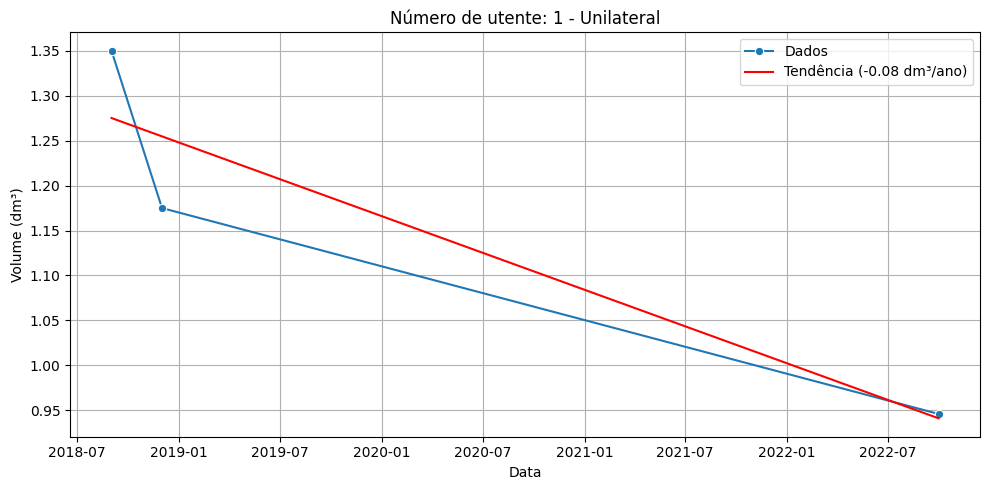

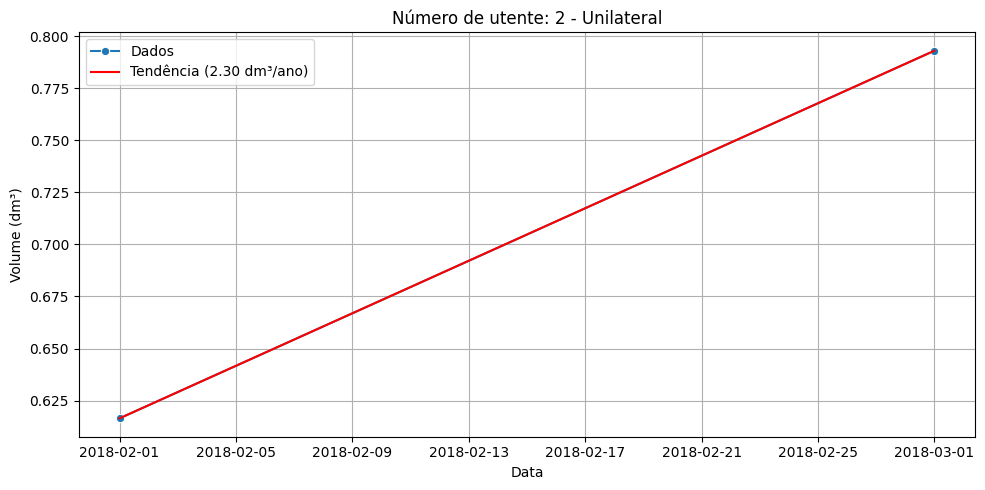

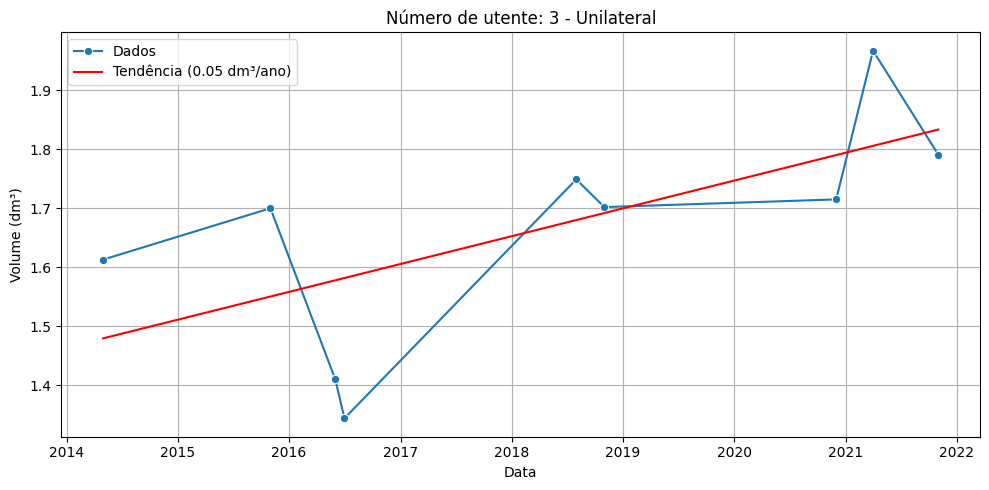

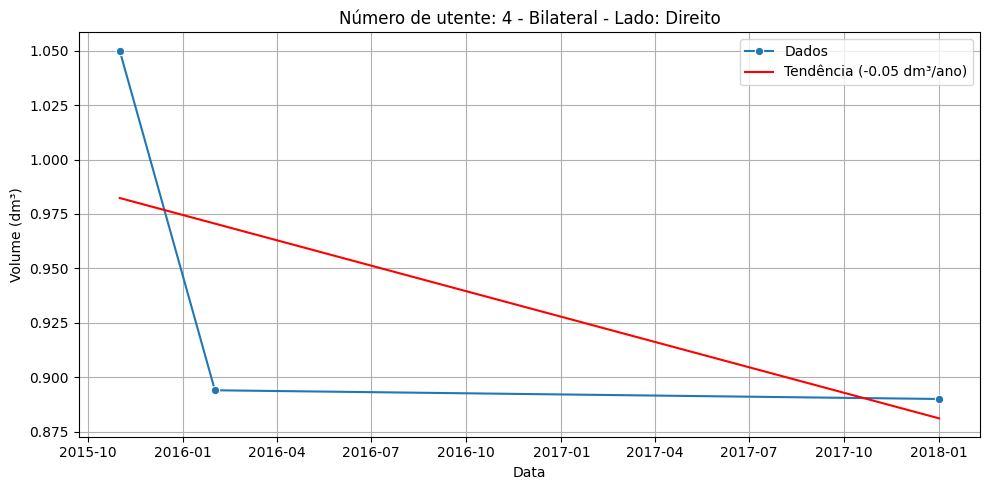

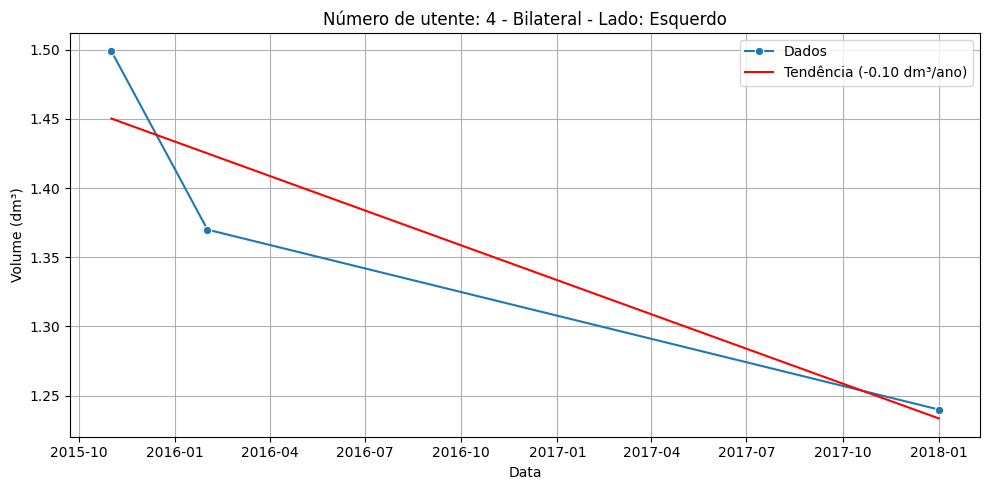

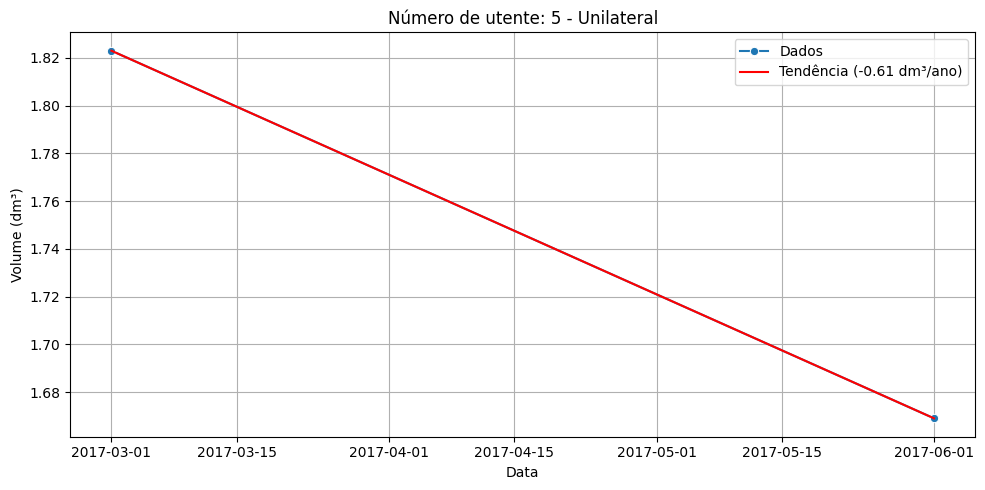

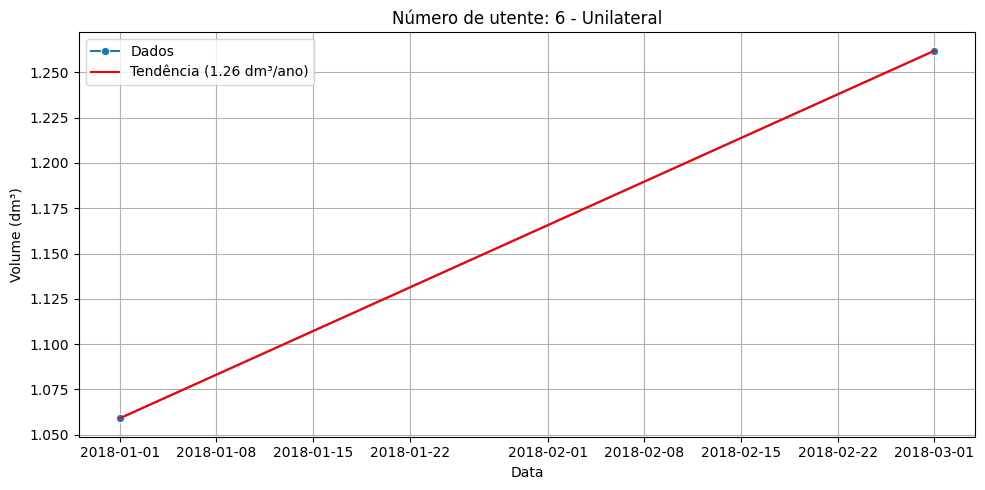

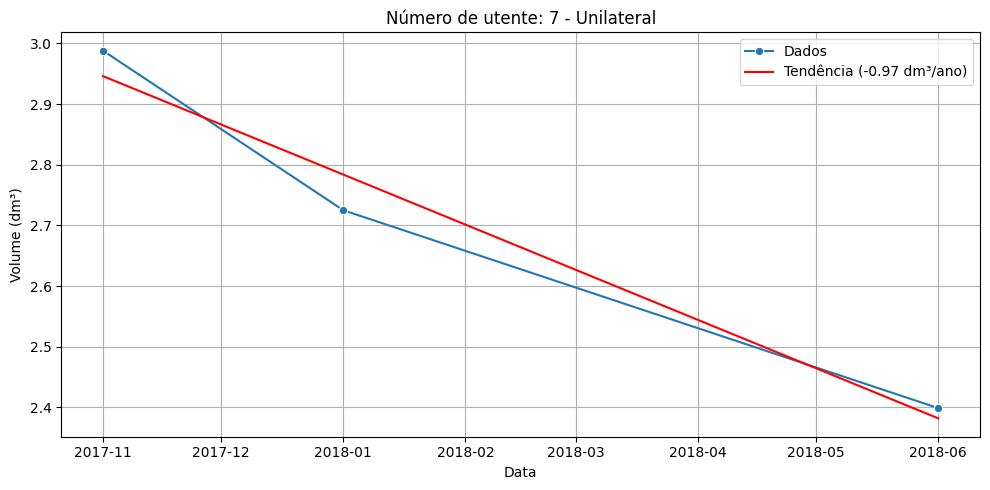

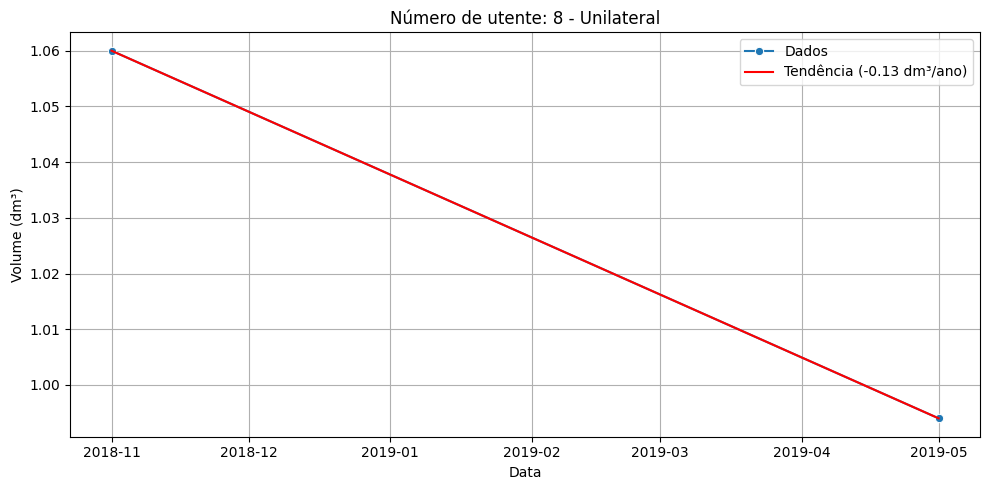

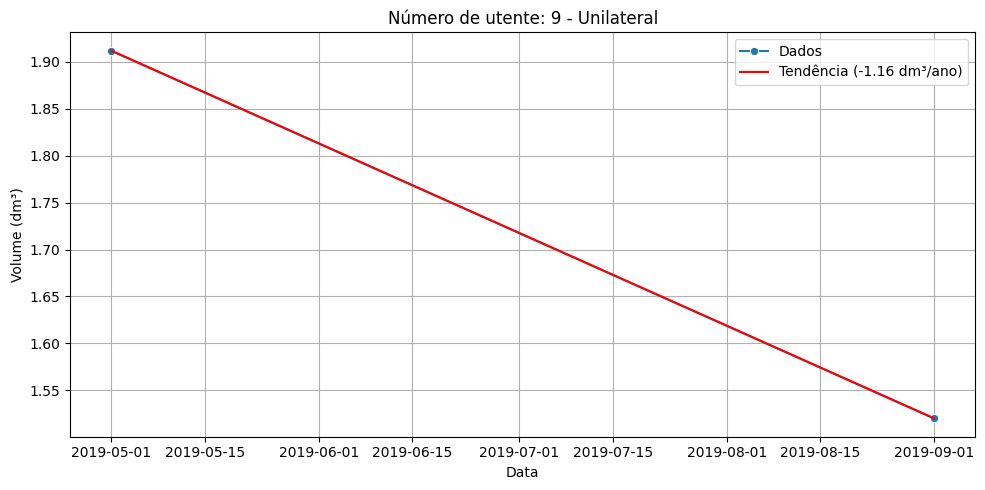

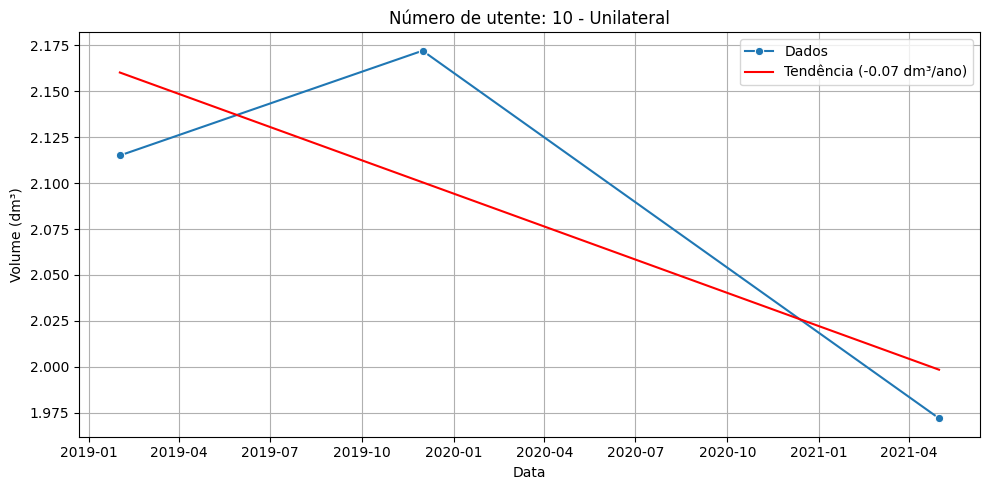

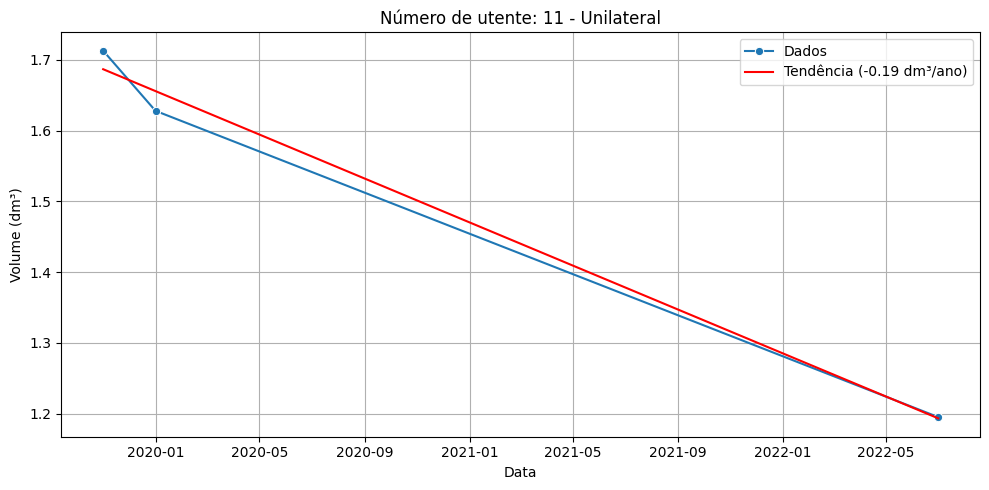

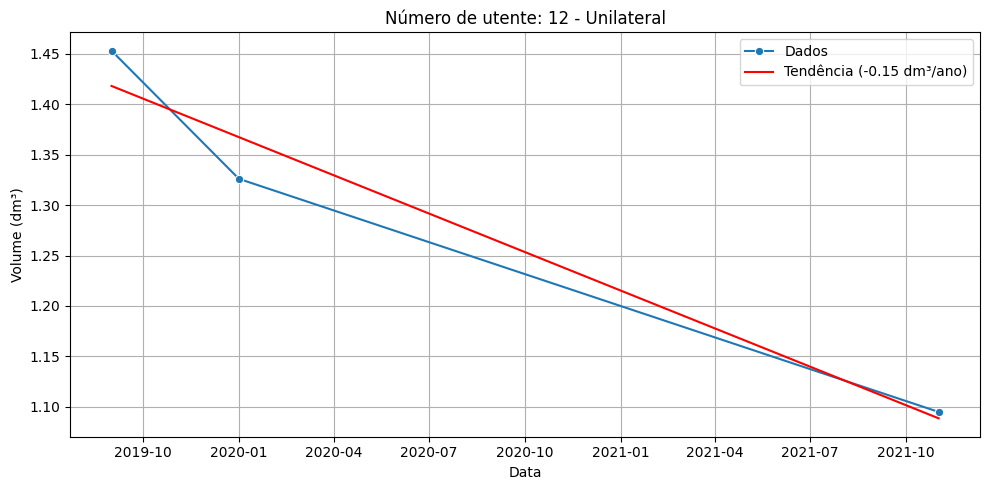

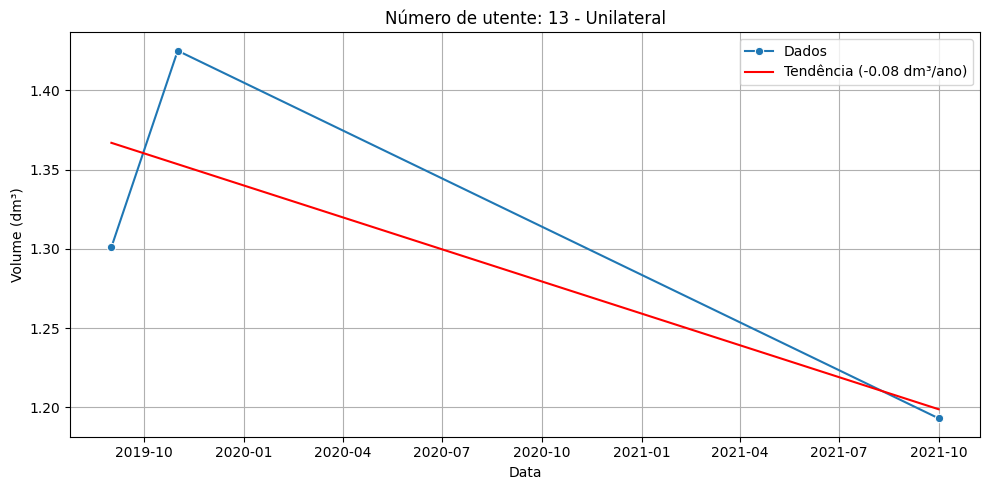

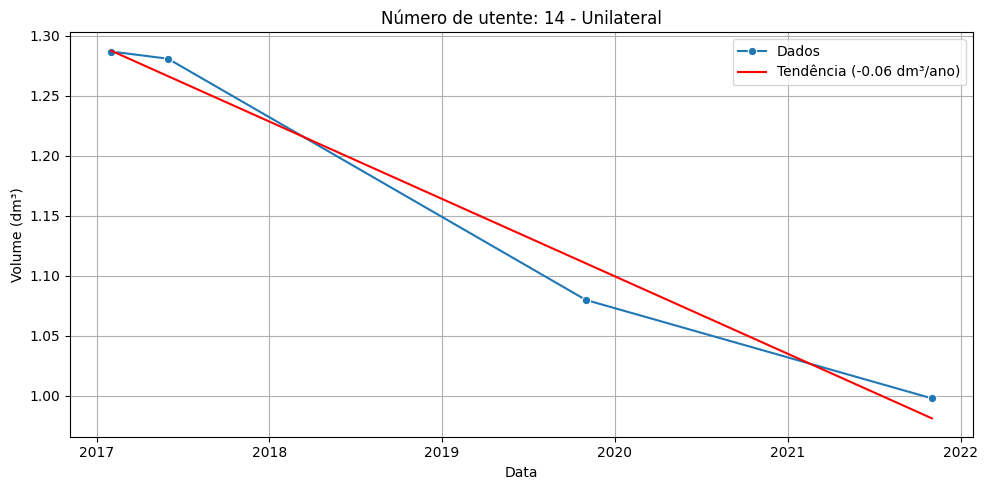

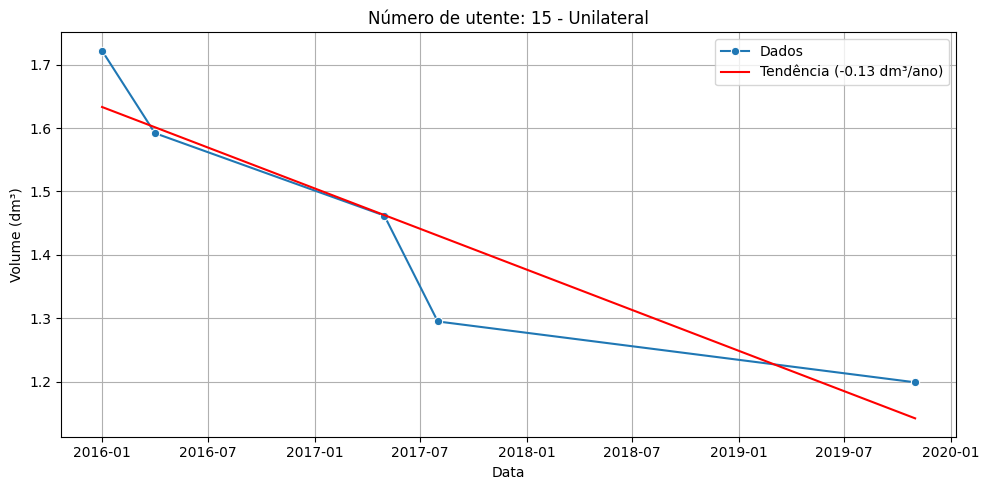

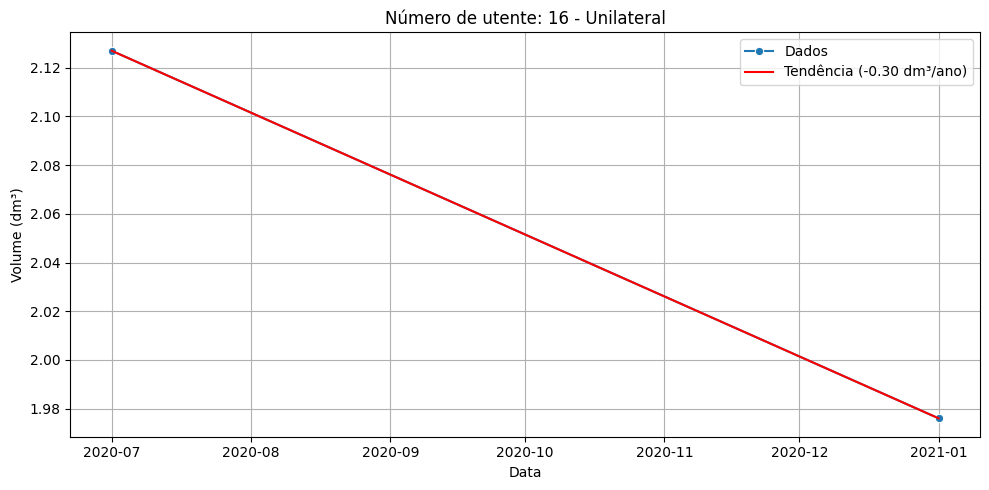

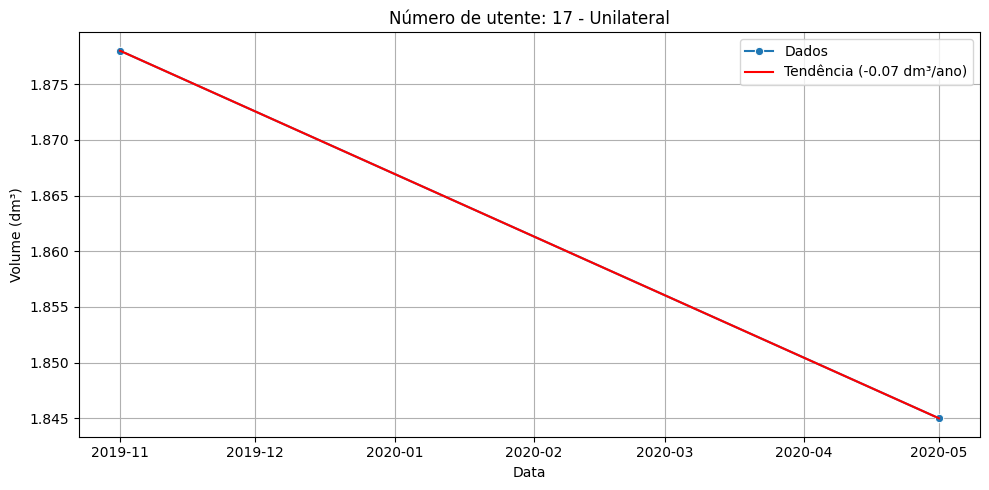

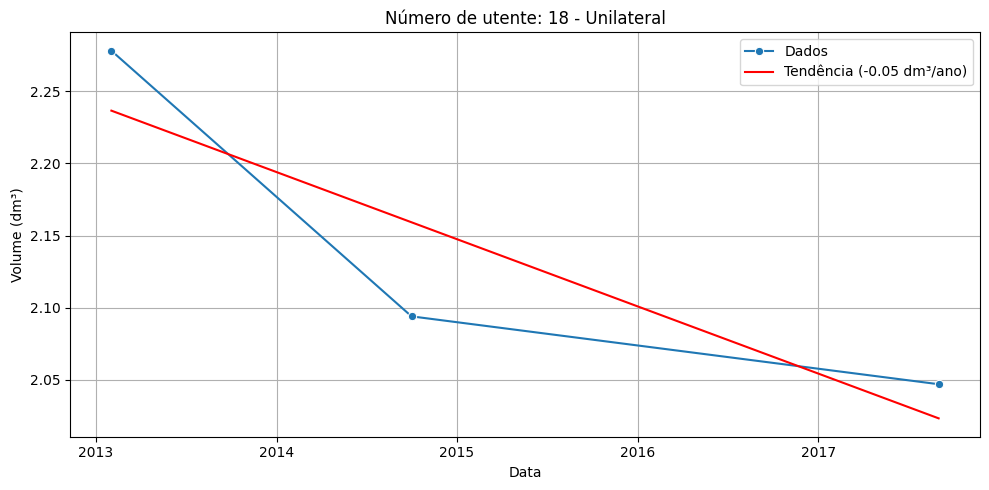

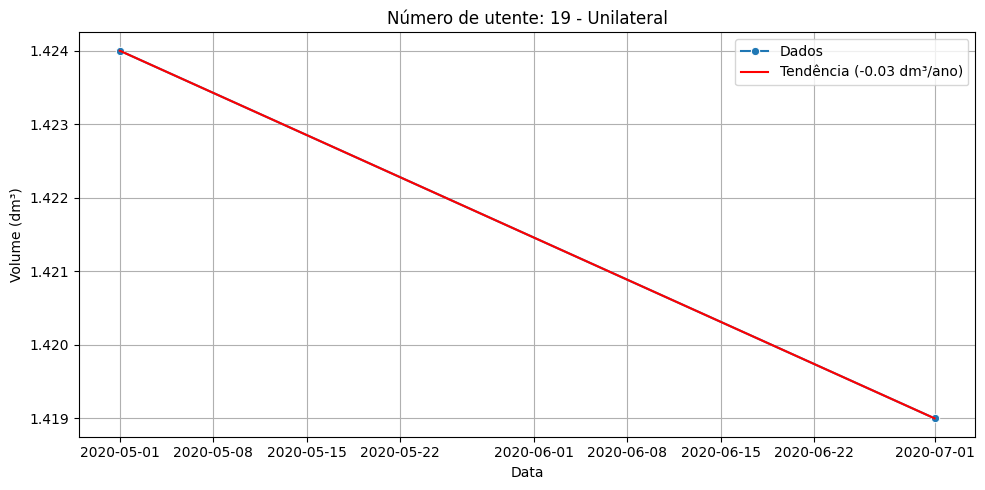

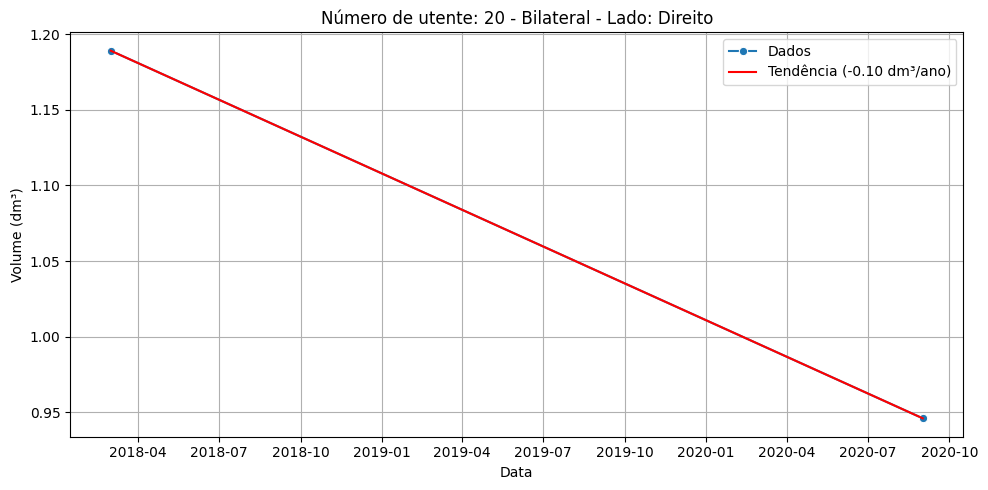

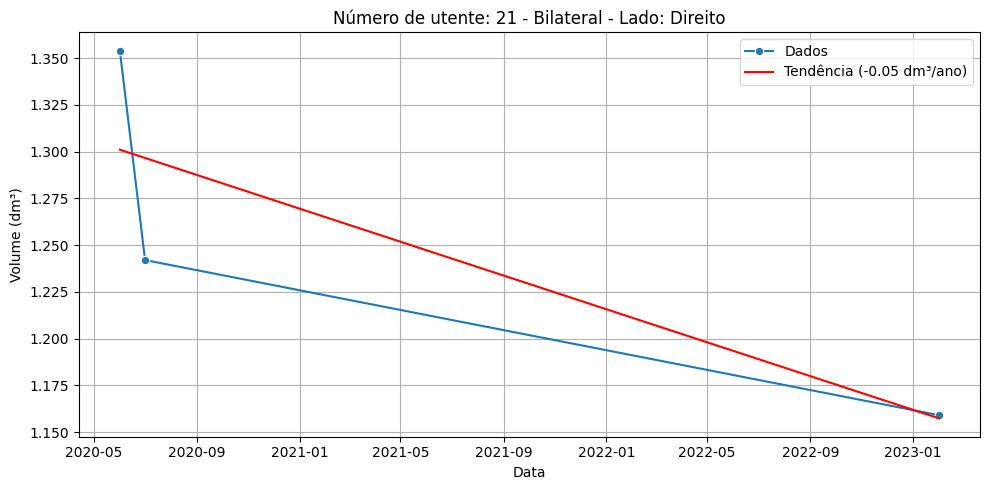

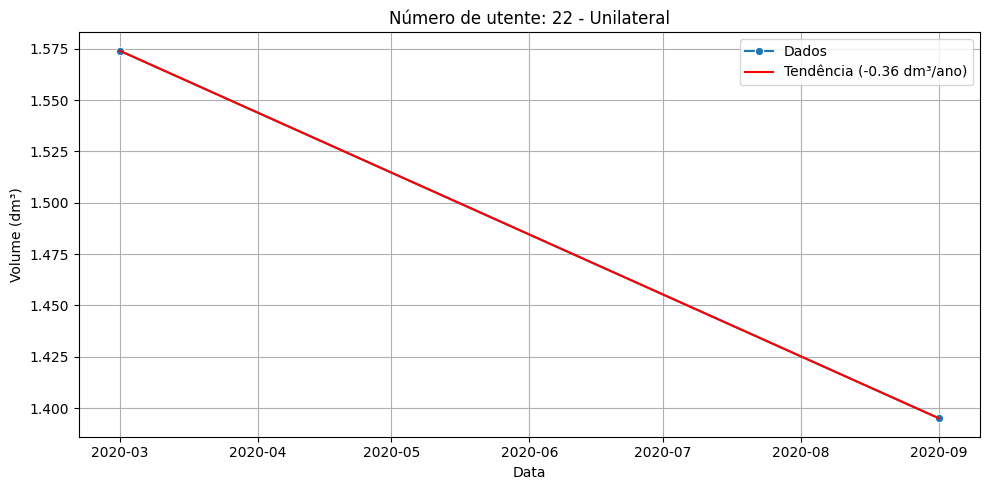

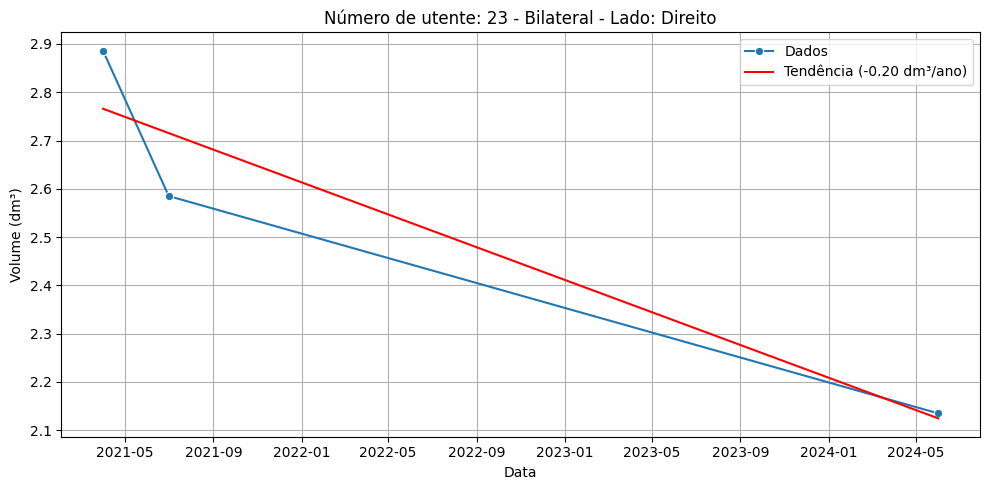

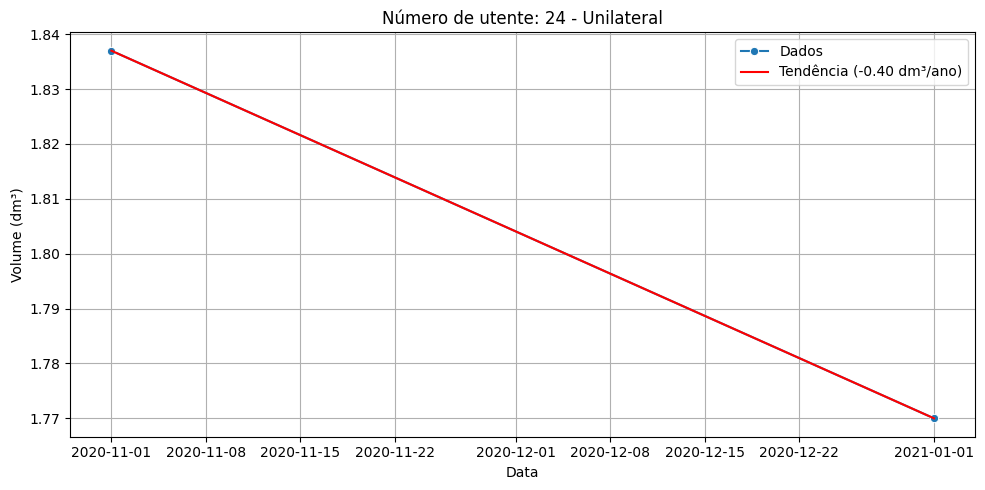

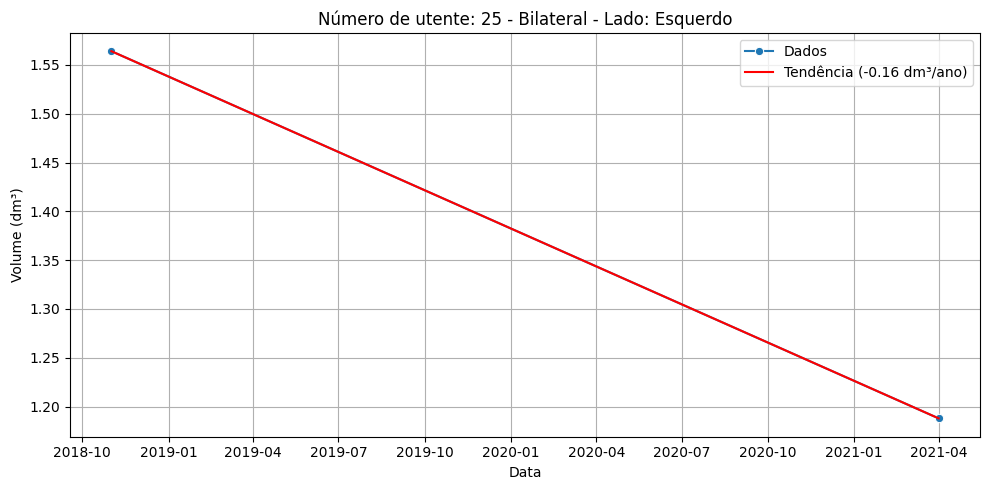

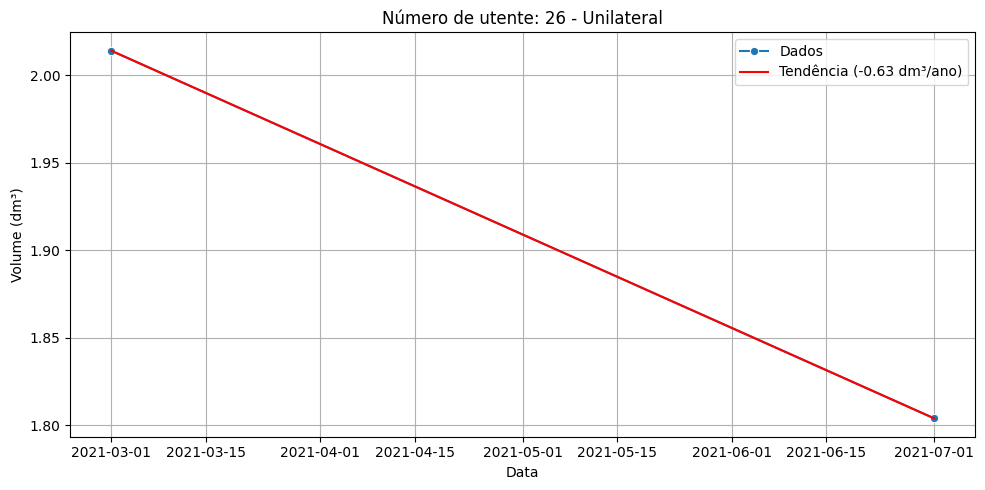

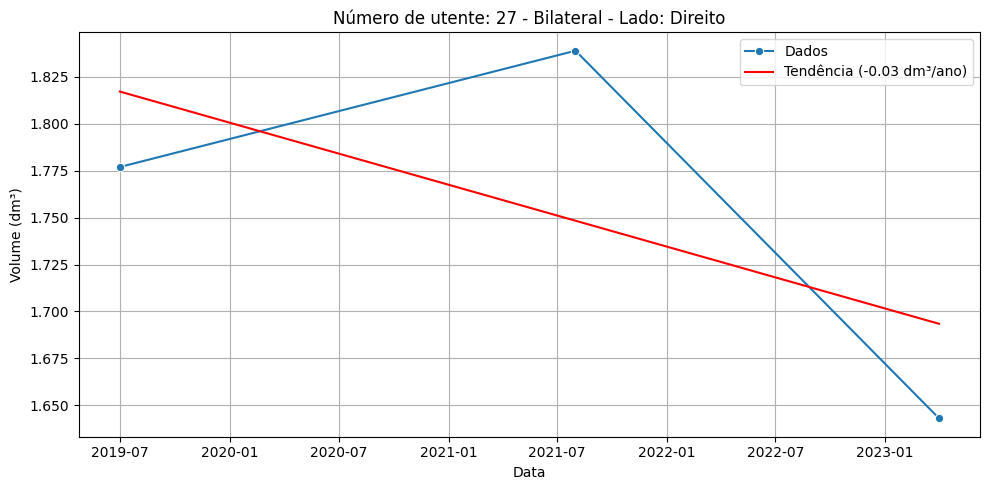

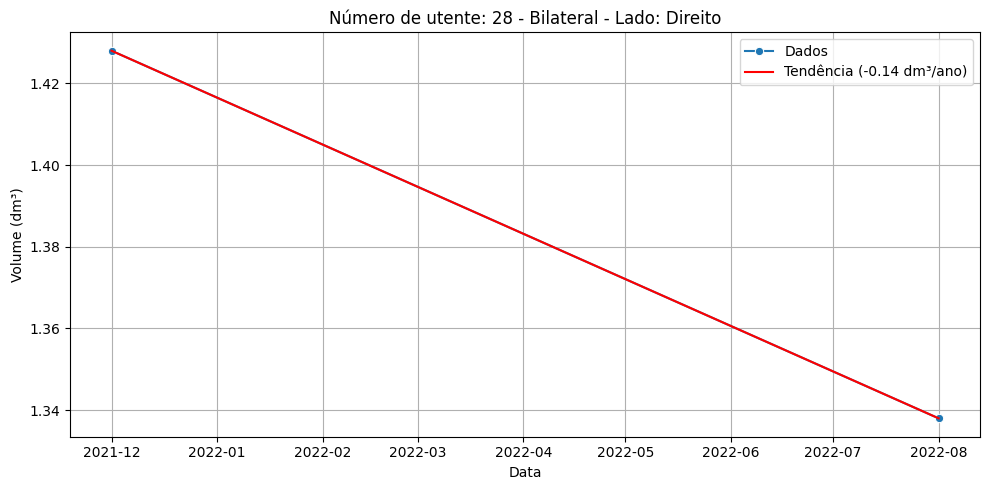

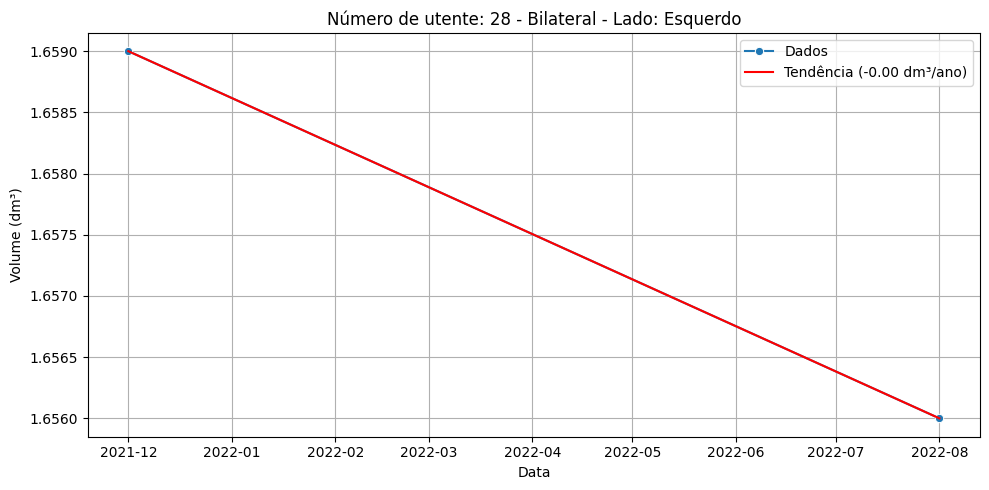

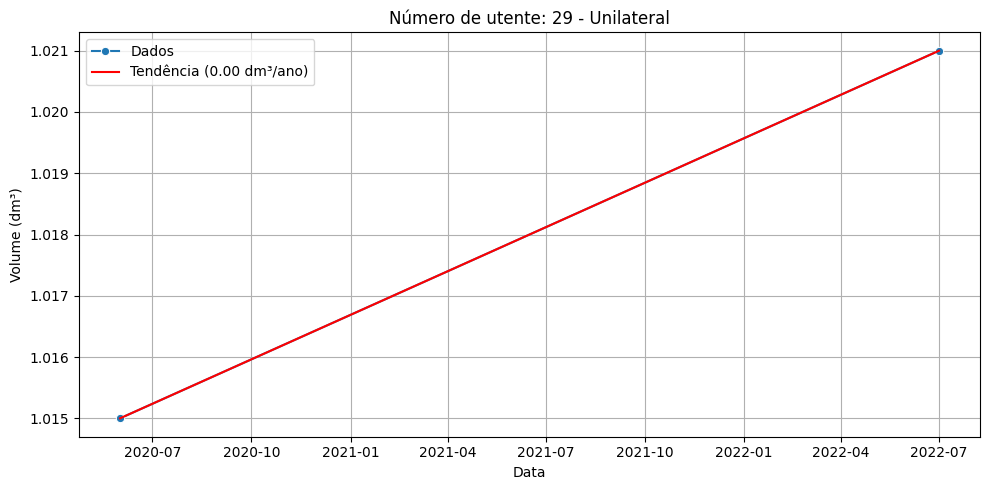

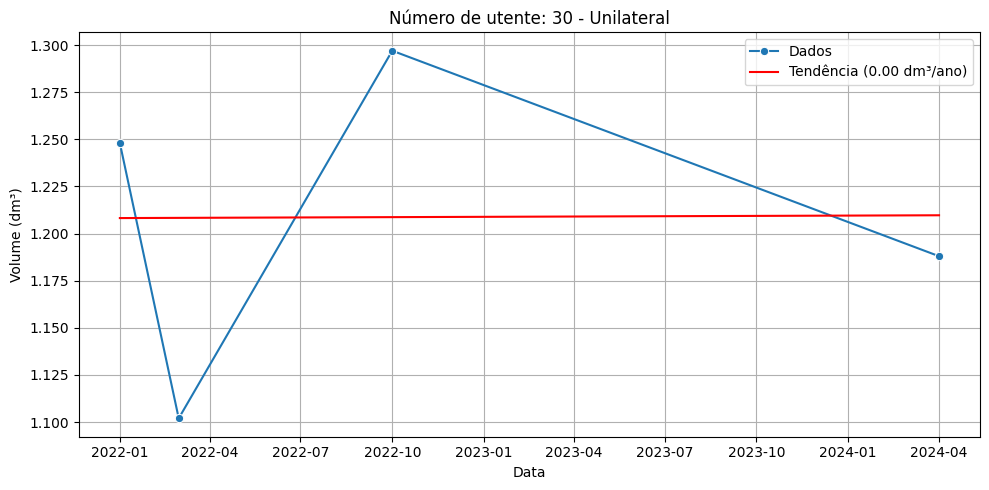

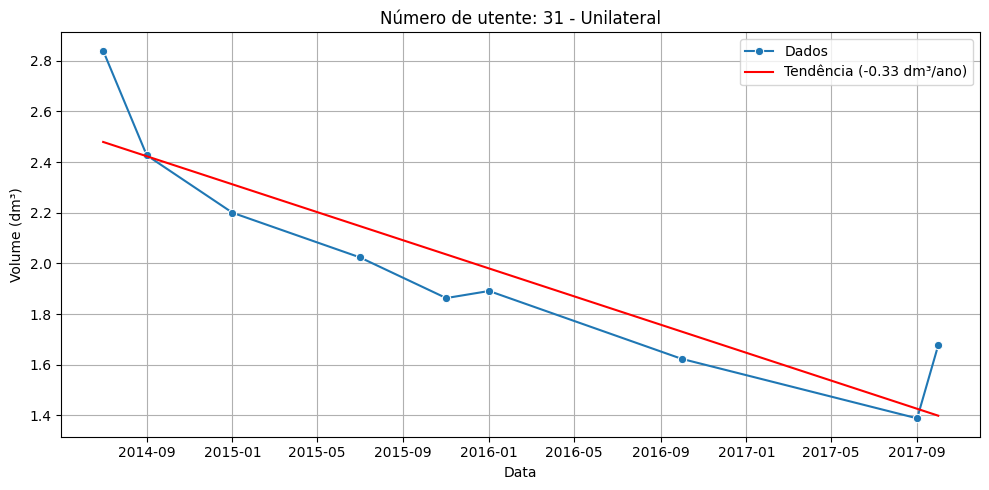

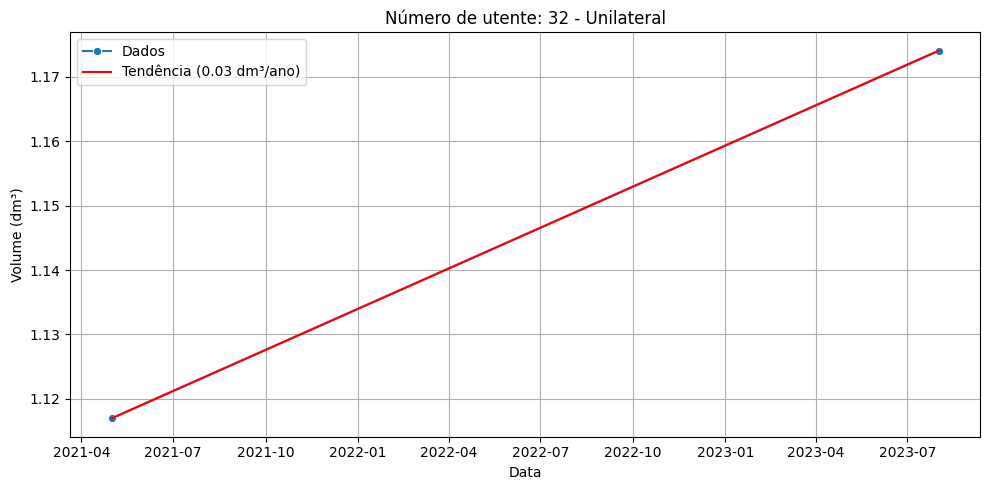

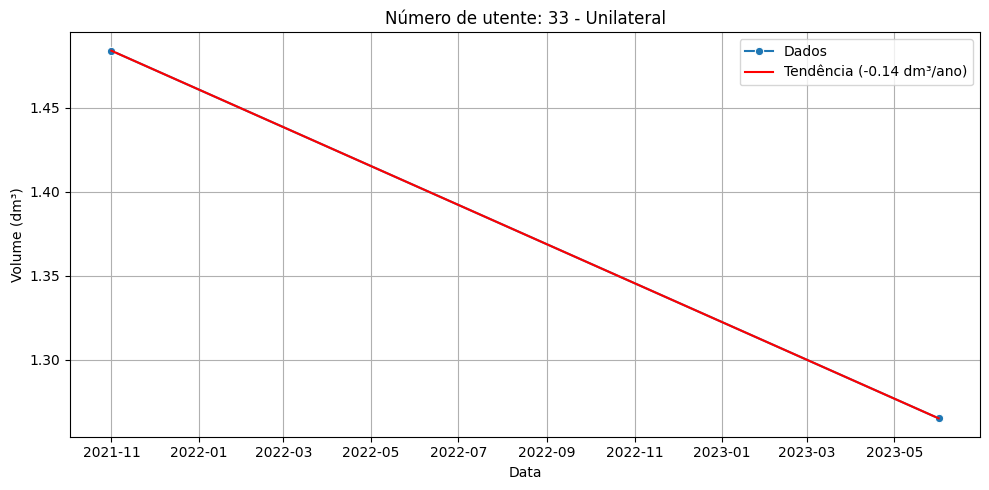

In [171]:

slopes = {}

for utente, group in data.groupby('Número de Utente'):
    group = group.dropna(subset=['Data', 'Volume (dm^3)']).sort_values('Data')
    
    # Assume que tens uma coluna 'Lateralidade' com valores 'Unilateral' ou 'Bilateral'
    lateralidade = group['Lateralidade'].iloc[0] if 'Lateralidade' in group.columns else 'Unilateral'
    
    if lateralidade == 'Unilateral':
        # Unilateral: plotar todos os dados juntos
        if len(group) > 0:
            x_years = group['Data'].map(pd.Timestamp.toordinal) / 365.25
            y = group['Volume (dm^3)']

            coeffs = np.polyfit(x_years, y, deg=1)
            slope = coeffs[0]
            slopes[(utente, None)] = slope

            plt.figure(figsize=(10, 5))
            sns.lineplot(x=group['Data'], y=y, marker='o', label='Dados')
            plt.plot(group['Data'], np.poly1d(coeffs)(x_years), color='red',
                     label=f'Tendência ({slope:.2f} dm³/ano)')
            plt.title(f'Número de utente: {utente} - Unilateral')
            plt.xlabel('Data')
            plt.ylabel('Volume (dm³)')
            plt.legend()
            plt.grid(True)
            plt.tight_layout()
            plt.show()
        else:
            slopes[(utente, None)] = np.nan
    
    elif lateralidade == 'Bilateral':
        # Bilateral: separar por Lado (Esquerdo/Direito)
        for lado, subgrp in group.groupby('Lado'):
            subgrp = subgrp.dropna(subset=['Data', 'Volume (dm^3)']).sort_values('Data')
            
            if len(subgrp) > 0:
                x_years = subgrp['Data'].map(pd.Timestamp.toordinal) / 365.25
                y = subgrp['Volume (dm^3)']

                coeffs = np.polyfit(x_years, y, deg=1)
                slope = coeffs[0]
                slopes[(utente, lado)] = slope

                plt.figure(figsize=(10, 5))
                sns.lineplot(x=subgrp['Data'], y=y, marker='o', label='Dados')
                plt.plot(subgrp['Data'], np.poly1d(coeffs)(x_years), color='red',
                         label=f'Tendência ({slope:.2f} dm³/ano)')
                plt.title(f'Número de utente: {utente} - Bilateral - Lado: {lado}')
                plt.xlabel('Data')
                plt.ylabel('Volume (dm³)')
                plt.legend()
                plt.grid(True)
                plt.tight_layout()
                plt.show()
            else:
                slopes[(utente, lado)] = np.nan
    
    else:
        print(f"Lateralidade desconhecida para utente {utente}: {lateralidade}")
        slopes[(utente, None)] = np.nan


In [172]:
print(slopes)

{(1, None): -0.08181808377562849, (2, None): 2.302379464268251, (3, None): 0.04714498728111047, (4, 'Direito'): -0.046680235367707525, (4, 'Esquerdo'): -0.099931367968119, (5, None): -0.6113967391309513, (6, None): 1.2567076271215172, (7, None): -0.9717563491730519, (8, None): -0.13318508287305855, (9, None): -1.1640487804843873, (10, None): -0.07201936625177034, (11, None): -0.18528886235171896, (12, None): -0.1519185682023438, (13, None): -0.08069502871810788, (14, None): -0.06451938206775332, (15, None): -0.12811045487431094, (16, None): -0.2997432065218846, (17, None): -0.06622664835164321, (18, None): -0.04652922514495299, (19, None): -0.029938524590098346, (20, 'Direito'): -0.09700081967212355, (21, 'Direito'): -0.05384444986582151, (22, None): -0.35532472826119355, (23, 'Direito'): -0.2023863821967886, (24, None): -0.4011762295085673, (25, 'Esquerdo'): -0.15570748299322637, (26, None): -0.6287090163927056, (27, 'Direito'): -0.03300883274241085, (28, 'Direito'): -0.13527777777774

In [173]:
data['Slope (dm³/ano)'] = np.nan

for (utente, lado), slope in slopes.items():
    if pd.isna(slope):
        continue  # skip NaN slopes

    if lado is None:
        # Unilateral: assign slope to all rows for this utente
        data.loc[data['Número de Utente'] == utente, 'Slope (dm³/ano)'] = slope
    else:
        # Bilateral: assign slope only for rows matching utente AND lado
        mask = (data['Número de Utente'] == utente) & (data['Lado'] == lado)
        data.loc[mask, 'Slope (dm³/ano)'] = slope

In [174]:
data.head()

,Número de Utente,Ano,Mês,Idade,Género,Formato,Lateralidade,Lado,Etiologia,Encaixe,Suspensão,Comprimento Descrição,Comprimento Valor(cm),Volume (dm^3),Mês_num,Data,Slope (dm³/ano)
0,1,2018,Dezembro,61,Feminino,Cilíndrico,Unilateral,Esquerdo,Vascular,PTB,PIN,Médio,14.20,1.1750,12,2018-12-01,-0.081818
1,1,2018,Setembro,61,Feminino,Cilíndrico,Unilateral,Esquerdo,Vascular,PTB,PIN,Médio,14.60,1.3500,9,2018-09-01,-0.081818
2,1,2022,Outubro,61,Feminino,Cilíndrico,Unilateral,Esquerdo,Vascular,PTB,PIN,Médio,12.99,0.9460,10,2022-10-01,-0.081818
3,2,2018,Fevereiro,82,Masculino,Cilíndrico,Unilateral,Esquerdo,Vascular,PTB,PIN,Curto,9.85,0.6165,2,2018-02-01,2.302379
4,2,2018,Março,82,Masculino,Cilíndrico,Unilateral,Esquerdo,Vascular,PTB,PIN,Curto,11.10,0.7930,3,2018-03-01,2.302379


In [175]:
data[data["Número de Utente"] == 28]

,Número de Utente,Ano,Mês,Idade,Género,Formato,Lateralidade,Lado,Etiologia,Encaixe,Suspensão,Comprimento Descrição,Comprimento Valor(cm),Volume (dm^3),Mês_num,Data,Slope (dm³/ano)
80,28,2021,Dezembro,54,Masculino,Cilíndrico,Bilateral,Esquerdo,Vascular,PTB,PIN,Longo,17.91,1.659,12,2021-12-01,-0.004509
81,28,2021,Dezembro,54,Masculino,Cilíndrico,Bilateral,Direito,Vascular,PTB,PIN,Médio,15.90,1.428,12,2021-12-01,-0.135278
82,28,2022,Agosto,54,Masculino,Cilíndrico,Bilateral,Direito,Vascular,PTB,PIN,Médio,16.41,1.338,8,2022-08-01,-0.135278
83,28,2022,Agosto,54,Masculino,Cilíndrico,Bilateral,Esquerdo,Vascular,PTB,PIN,Longo,18.77,1.656,8,2022-08-01,-0.004509


In [176]:
data = data[["Número de Utente", "Idade", "Género", "Lado", "Lateralidade", "Etiologia", "Encaixe", "Suspensão", "Slope (dm³/ano)"]]
print(data.shape)
data.head()

(103, 9)


,Número de Utente,Idade,Género,Lado,Lateralidade,Etiologia,Encaixe,Suspensão,Slope (dm³/ano)
0,1,61,Feminino,Esquerdo,Unilateral,Vascular,PTB,PIN,-0.081818
1,1,61,Feminino,Esquerdo,Unilateral,Vascular,PTB,PIN,-0.081818
2,1,61,Feminino,Esquerdo,Unilateral,Vascular,PTB,PIN,-0.081818
3,2,82,Masculino,Esquerdo,Unilateral,Vascular,PTB,PIN,2.302379
4,2,82,Masculino,Esquerdo,Unilateral,Vascular,PTB,PIN,2.302379


In [177]:
data = data.drop_duplicates()
print(data.shape)
data.head()

(35, 9)


,Número de Utente,Idade,Género,Lado,Lateralidade,Etiologia,Encaixe,Suspensão,Slope (dm³/ano)
0,1,61,Feminino,Esquerdo,Unilateral,Vascular,PTB,PIN,-0.081818
3,2,82,Masculino,Esquerdo,Unilateral,Vascular,PTB,PIN,2.302379
5,3,46,Masculino,Esquerdo,Unilateral,Traumática,PTB,PIN,0.047145
14,4,69,Masculino,Esquerdo,Bilateral,Vascular,PTB,PIN,-0.099931
15,4,69,Masculino,Direito,Bilateral,Vascular,PTB,PIN,-0.046680


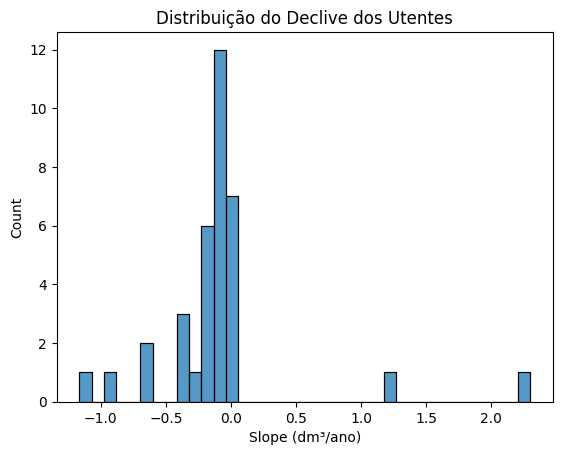

In [189]:
sns.histplot(data = data, x = "Slope (dm³/ano)")
plt.title("Distribuição do Declive dos Utentes")
plt.show()

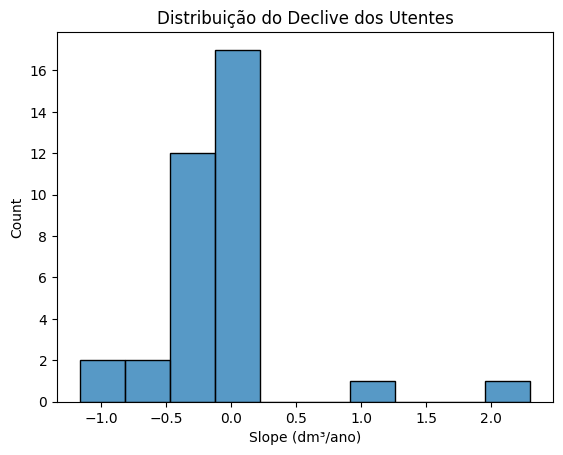

In [178]:
sns.histplot(data = data, x = "Slope (dm³/ano)", bins = 10)
plt.title("Distribuição do Declive dos Utentes")
plt.show()

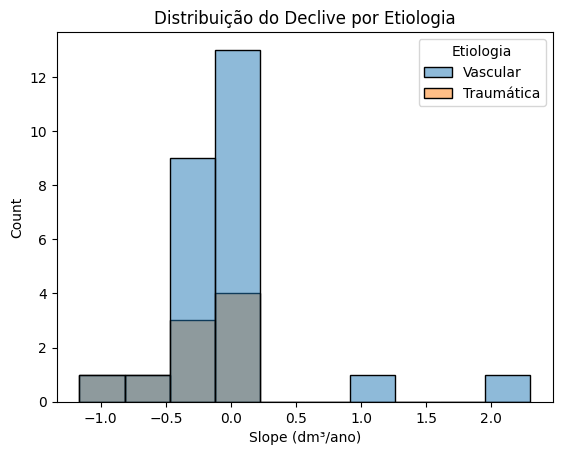

In [179]:
sns.histplot(data = data, x = "Slope (dm³/ano)", bins = 10, hue = "Etiologia")
plt.title("Distribuição do Declive por Etiologia")
plt.show()

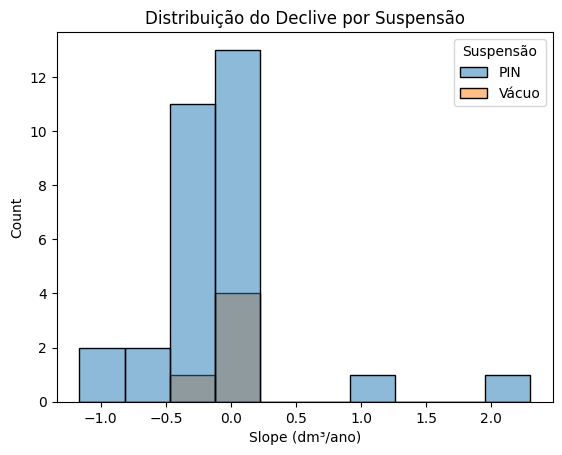

In [180]:
sns.histplot(data = data, x = "Slope (dm³/ano)", bins = 10, hue = "Suspensão")
plt.title("Distribuição do Declive por Suspensão")
plt.show()

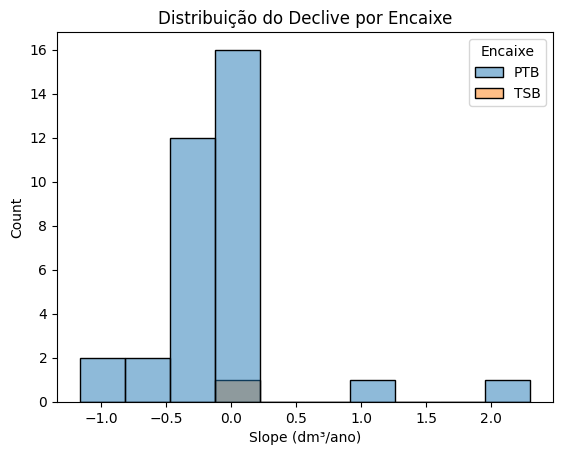

In [181]:
sns.histplot(data = data, x = "Slope (dm³/ano)", bins = 10, hue = "Encaixe")
plt.title("Distribuição do Declive por Encaixe")
plt.show()

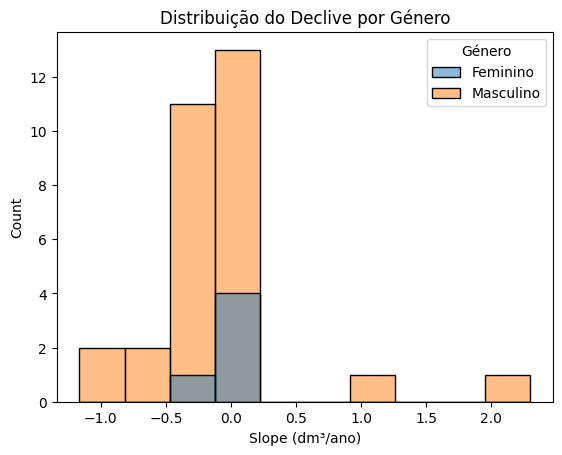

In [182]:
sns.histplot(data = data, x = "Slope (dm³/ano)", bins = 10, hue = "Género")
plt.title("Distribuição do Declive por Género")
plt.show()

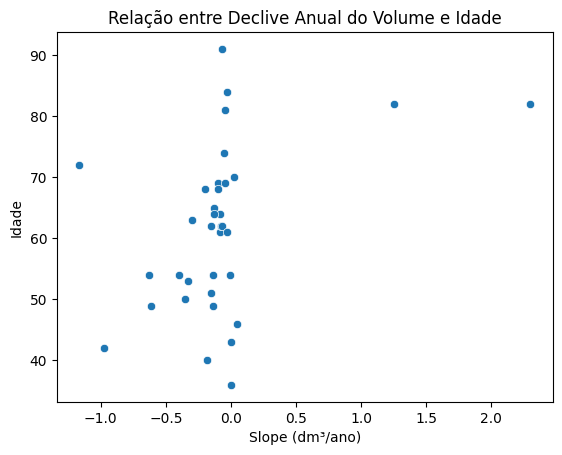

In [188]:
sns.scatterplot(data = data, x= "Slope (dm³/ano)", y="Idade")
plt.title("Relação entre Declive Anual do Volume e Idade")
plt.show()